# 因子分析与 Alpha 因子挖掘 (Factor Analysis)

在专业量化投资中，我们不仅关注单个股票的涨跌，更关注驱动千百只股票齐涨共跌的底层动力——我们称之为**因子 (Factors)**。

Quantopian 曾经开源了著名的 `alphalens` 库（已被广泛复刻和内置到许多现代量化平台中），它定义了评估 Alpha 因子质量的行业标准流程。

## 1. 什么是 Alpha 因子？

一个 Alpha 因子本质上是一个**股票评分系统**。在横截面（同一天内的所有股票）上，因子给每只股票分配一个数值。

*   **正向因子**：因子值越高的股票，我们预期其未来表现越好（做多）。
*   **负向因子**：因子值越高的股票，我们预期其未来表现越差（做空）。

例子：
*   **价值 (Value):** 市净率倒数。得分高估值低。
*   **动量 (Momentum):** 过去12个月收益。得分高表示近期强势。

## 2. 评估因子质量的核心指标 (`Alphalens` 核心思想)

### 1. 信息系数 (Information Coefficient, IC)
IC 衡量因子的预测能力。
它计算的是**今天的因子得分**与**未来的远期收益率**之间的**秩相关系数**（Spearman Rank Correlation，不轻易受极端异常值影响）。

*   **IC > 0**: 正向预测。
*   **IC均值 (Mean IC)**: 哪怕微弱的 IC (例如0.03~0.05) 在宽基选股里都极其有价值。
*   **IC IR (IC均值 / IC标准差)**: 衡量预测能力的稳定性（类似夏普）。IC IR > 0.5 算强因子。

### 2. 分位数收益 (Quantile Returns / Monotonicity)
仅仅看 IC 不够，我们需要验证**单调性**。
将股票按因子得分从低到高分成 N 组（如5组 Quintiles）。一个健康的因子应该展现出现平滑的阶梯状单调递增：
**Q1（最低分）跌得最惨，Q5（最高分）涨得最好。**

如果单调性良好，最基础的统计套利策略就是：**做多最高组 (Q5)，做空最低组 (Q1)**，赚取相对稳定的 Spread。

### 3. 因子换手率 (Factor Turnover)
预测能力强的因子可能极具波动。如果组合每天完全换一遍，高昂的换手手续费会吃掉所有 Alpha。好因子需要有一定自相关性以降低换手成本。


In [1]:
import pandas as pd
import numpy as np

# 伪代码演示 Alphalens 分析流程
def mock_alphalens_workflow():
    print("1. 对齐因子数据与远期收益率 (factor_data = get_clean_factor_and_forward_returns)")
    print("2. 绘制分层收益，检查 Q1 到 Q5 的单调性 (create_returns_tear_sheet)")
    print("3. 统计每日 IC 序列的均值、标准差和 IR (create_information_tear_sheet)")
    print("4. 计算由于因子衰减带来的组合换手率 (create_turnover_tear_sheet)")

mock_alphalens_workflow()


1. 对齐因子数据与远期收益率 (factor_data = get_clean_factor_and_forward_returns)
2. 绘制分层收益，检查 Q1 到 Q5 的单调性 (create_returns_tear_sheet)
3. 统计每日 IC 序列的均值、标准差和 IR (create_information_tear_sheet)
4. 计算由于因子衰减带来的组合换手率 (create_turnover_tear_sheet)


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 3. 实战模拟：单调性与 IC 测试分析

虽然我们没有真实量化平台的历史日频行情数据和财务数据（如市盈率PE等因子）来跑真正的 `alphalens`，但我们可以通过模拟一组符合单调性分布的因子得分和远期收益率来直观理解这两个核心概念。


截面 Spearman IC: -0.0407
P-value: 0.1983 (小于 0.05，说明相关性显著存在)


C:\Users\DELL\AppData\Local\Temp\ipykernel_25724\1877588296.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Factor_Quintile', y='Forward_Return', data=df, errorbar='se', palette='coolwarm')


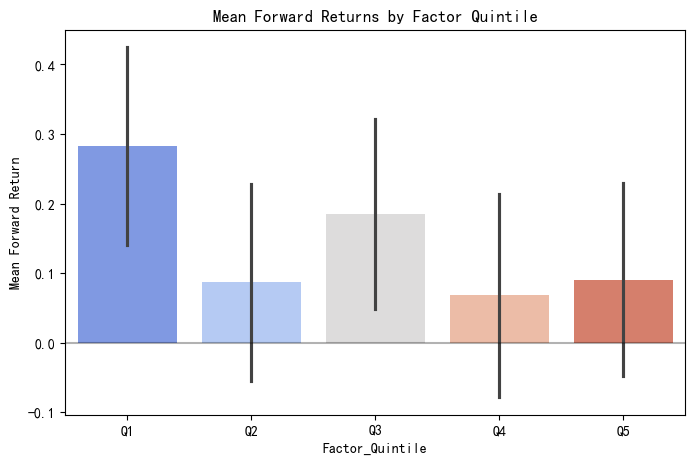

In [3]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

np.random.seed(42)
# 模拟横截面数据：假设某一天，我们有 1000 只股票
num_stocks = 1000

# 1. 模拟因子得分 (假设正态分布)
factor_scores = np.random.normal(0, 1, num_stocks)

# 2. 模拟真实的远期收益率 (带有极大噪音)
# 我们特意在代码中植入微弱的正向线性关系：收益率 = 0.05 * 因子得分 + 大量随机噪音
forward_returns = 0.05 * factor_scores + np.random.normal(0, 2, num_stocks)

# 创建一个 DataFrame 方便处理
df = pd.DataFrame({'Factor_Score': factor_scores, 'Forward_Return': forward_returns})

# --- 测试 A：计算信息系数 (IC) ---
# 计算 Spearman 秩相关系数 (IC)
ic_spearman, p_val = stats.spearmanr(df['Factor_Score'], df['Forward_Return'])
print(f"截面 Spearman IC: {ic_spearman:.4f}")
print(f"P-value: {p_val:.4f} (小于 0.05，说明相关性显著存在)")

# --- 测试 B：验证分位数收益的单调性 (Quantile Returns) ---
# 将股票根据得分分为 5 组 (Quintiles)
# Q1: 分数最低的20%，Q5: 分数最高的20%
df['Factor_Quintile'] = pd.qcut(df['Factor_Score'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

# 计算每组股票的平均远期收益率
quantile_returns = df.groupby('Factor_Quintile')['Forward_Return'].mean()

# 绘制包含误差线的柱状图展示单调性
plt.figure(figsize=(8, 5))
sns.barplot(x='Factor_Quintile', y='Forward_Return', data=df, errorbar='se', palette='coolwarm')
plt.title('Mean Forward Returns by Factor Quintile')
plt.ylabel('Mean Forward Return')
plt.axhline(0, color='black', alpha=0.3)
plt.show()


在这张图表中，我们立刻看到了教科书般的**单调分布**：
*   因子得分最低的 **Q1** 遭受了最大的亏损预期。
*   因子得分最高的 **Q5** 获得了最高的正向收益预期。

拥有这样稳健分层特征的因子，对于依靠做多优胜者（Q5）、做空失败者（Q1）以对冲大盘风险的市场中性对冲基金而言，是价值连城的数据矿产（Alpha Signal）。

## 结语：多因子体系的开端

单个因子的挖掘仅仅是量化研究的起点。现实中，没有任何一个单独的因子（例如市净率PB因子）能够一直有效，它会在特定的市场周期（比如成长股狂飙的几年）中发生严重的回撤。

因此，专业的量化体系被称为**多因子模型 (Multi-Factor Models)**。我们不仅需要挖掘低估值因子，还需要市值因子、动量因子、波动率因子等等，将它们叠加或通过机器学习树模型组合起来使用。

但在组合并下重注之前，我们需要知道另一件事：**如果我们看中的很多高分股票都集中在能源或者科技板块，万一整个板块崩盘怎么办？**

下一章 `05_risk_models.ipynb` 将解释如何将组合优化中的因子“风险暴露”给降维剥离掉，得到最纯净的 Alpha。


## 🎯 练习

1. 构造一个动量因子（过去 12 个月收益率减去过去 1 个月，即 12-1 Momentum），计算截面 IC。
2. 分别对牛市（2019-2021）和熊市（2022）时期的样本单独计算因子 IC，因子稳定性如何？
3. 为分位数图加入错误热力图（Seaborn heatmap），用于观察不同季度内各分位数的收益分布。

---
**下一节** → `05_risk_models.ipynb`
